In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# cleaner plots
plt.rcParams["figure.figsize"] = (8,5)

# load dataset (FIXED)
df = pd.read_csv("cardio_train.csv", sep=";")

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


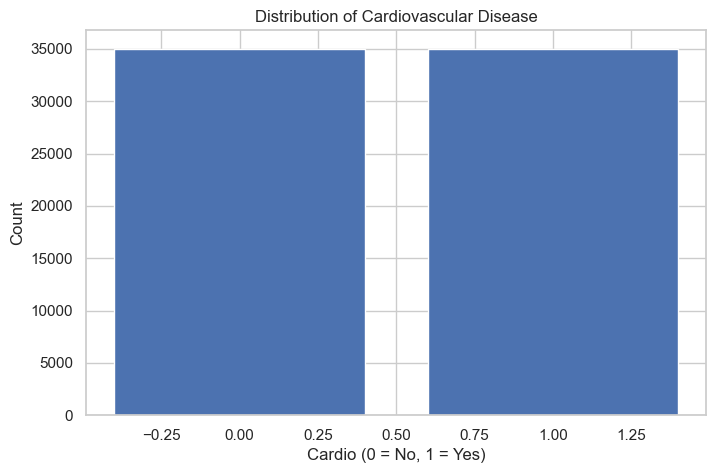

In [18]:
counts = df["cardio"].value_counts().sort_index()

plt.bar(counts.index, counts.values)
plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardio (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [24]:
# age is in days → convert to years (easier to interpret)
df["age_years"] = df["age"] / 365

df["age_years"].head()

0    50.391781
1    55.419178
2    51.663014
3    48.282192
4    47.873973
Name: age_years, dtype: float64

In [23]:
# create age groups for analysis
# using bins roughly by decades

df["age_cat"] = pd.cut(
    df["age_years"],
    bins=[30,40,50,60,70],
    labels=["30-40","40-50","50-60","60-70"]
)

df["age_cat"].value_counts()

age_cat
50-60    35547
40-50    19636
60-70    13025
30-40     1789
Name: count, dtype: int64

age_cat
30-40    0.243153
40-50    0.379405
50-60    0.516640
60-70    0.670173
Name: cardio, dtype: float64


/var/folders/lb/yn2bzgmn34z_b9t4r4f9ls8c0000gn/T/ipykernel_42281/1251372857.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_cardio = df.groupby("age_cat")["cardio"].mean()


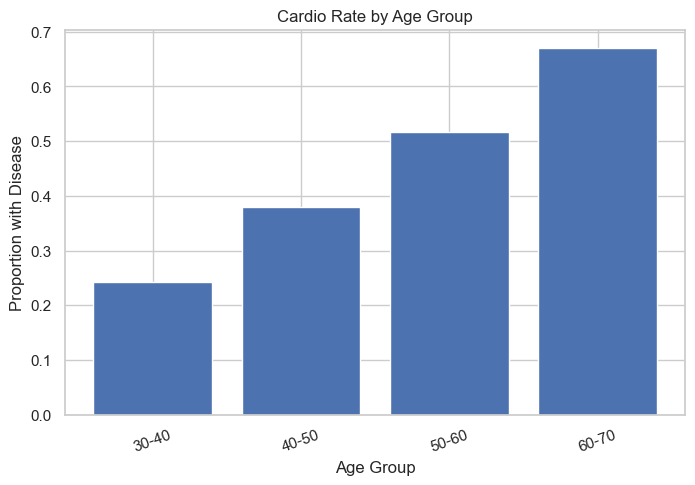

In [25]:
# mean of cardio = proportion with disease
age_cardio = df.groupby("age_cat")["cardio"].mean()

print(age_cardio)

# plot it
plt.bar(age_cardio.index.astype(str), age_cardio.values)

plt.title("Cardio Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion with Disease")

plt.xticks(rotation=20)
plt.show()

In [26]:
# check correlation of all numeric features with cardio
corr = df.corr(numeric_only=True)["cardio"].sort_values(ascending=False)

print(corr)

cardio         1.000000
age            0.238159
age_years      0.238159
cholesterol    0.221147
weight         0.181660
gluc           0.089307
ap_lo          0.065719
ap_hi          0.054475
gender         0.008109
id             0.003799
alco          -0.007330
height        -0.010821
smoke         -0.015486
active        -0.035653
Name: cardio, dtype: float64


In [27]:
# checking how correlation changes across age groups

for grp in sorted(df["age_cat"].dropna().unique()):
    
    subset = df[df["age_cat"] == grp]
    
    corr_vals = subset.corr(numeric_only=True)["cardio"].drop("cardio")
    
    print("\nAge Group:", grp)
    print(corr_vals.sort_values(ascending=False).head(5))


Age Group: 30-40
ap_hi          0.314900
cholesterol    0.245597
weight         0.245117
gluc           0.113183
height         0.070734
Name: cardio, dtype: float64

Age Group: 40-50
cholesterol    0.237081
weight         0.225544
age_years      0.136714
age            0.136714
ap_lo          0.090440
Name: cardio, dtype: float64

Age Group: 50-60
cholesterol    0.196011
weight         0.171453
age_years      0.112522
age            0.112522
gluc           0.077198
Name: cardio, dtype: float64

Age Group: 60-70
cholesterol    0.166634
weight         0.106460
age_years      0.097478
age            0.097478
ap_lo          0.041544
Name: cardio, dtype: float64


<Figure size 800x500 with 0 Axes>

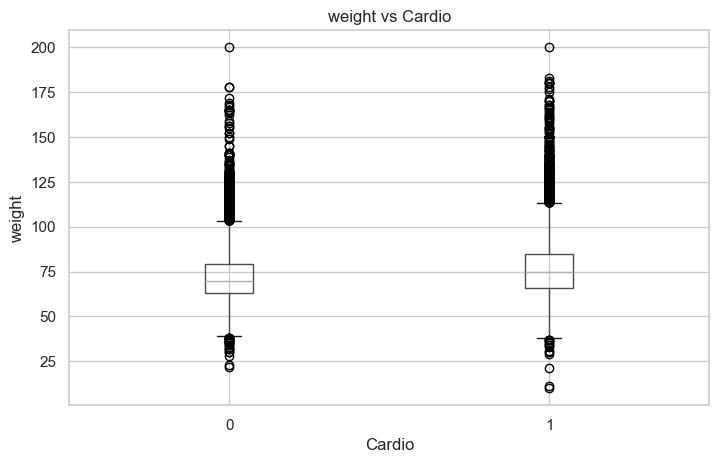

<Figure size 800x500 with 0 Axes>

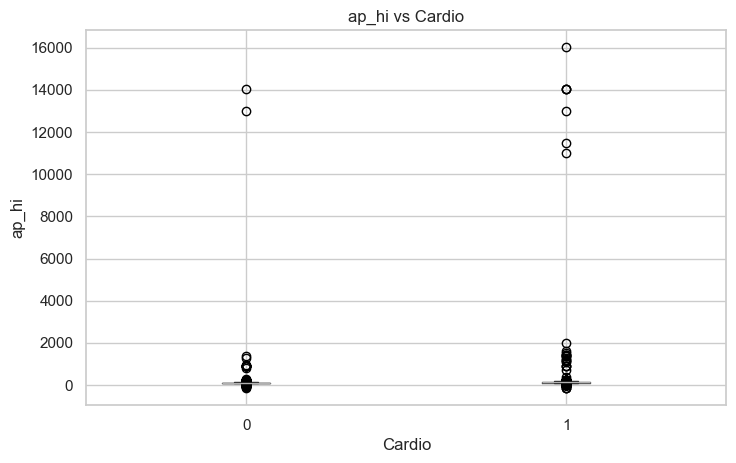

<Figure size 800x500 with 0 Axes>

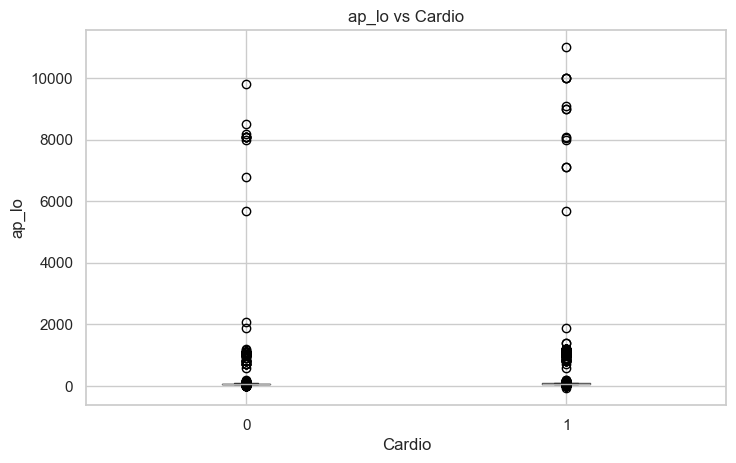

In [28]:
# comparing distributions between cardio vs no cardio
# using boxplot (matplotlib version)

features = ["weight", "ap_hi", "ap_lo"]

for col in features:
    plt.figure()
    
    df.boxplot(column=col, by="cardio")
    
    plt.title(f"{col} vs Cardio")
    plt.suptitle("")  # remove default weird title
    plt.xlabel("Cardio")
    plt.ylabel(col)
    
    plt.show()

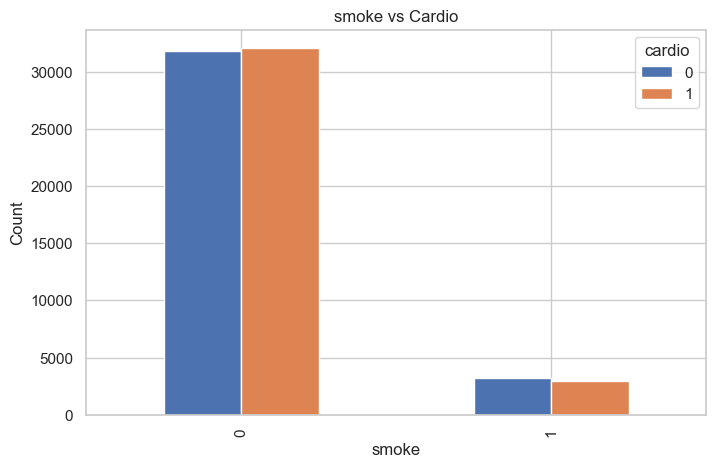

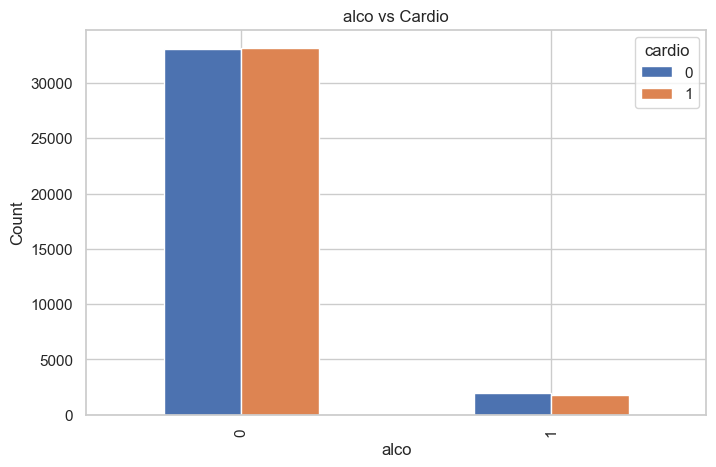

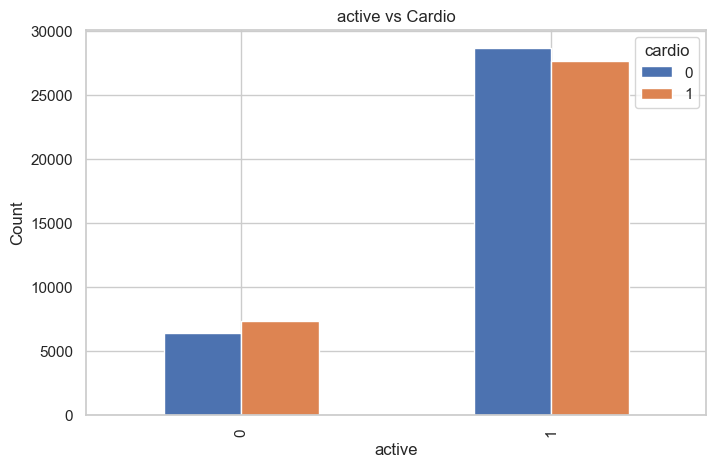

In [29]:
# checking categorical lifestyle features

for col in ["smoke", "alco", "active"]:
    
    grouped = df.groupby([col, "cardio"]).size().unstack()
    
    grouped.plot(kind="bar")
    
    plt.title(f"{col} vs Cardio")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.show()

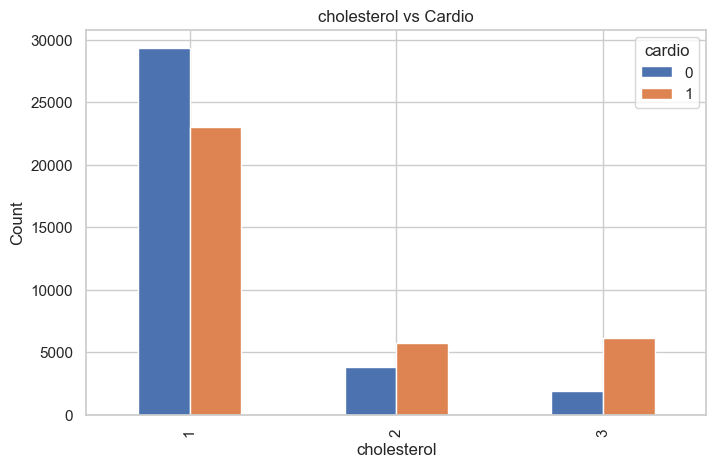

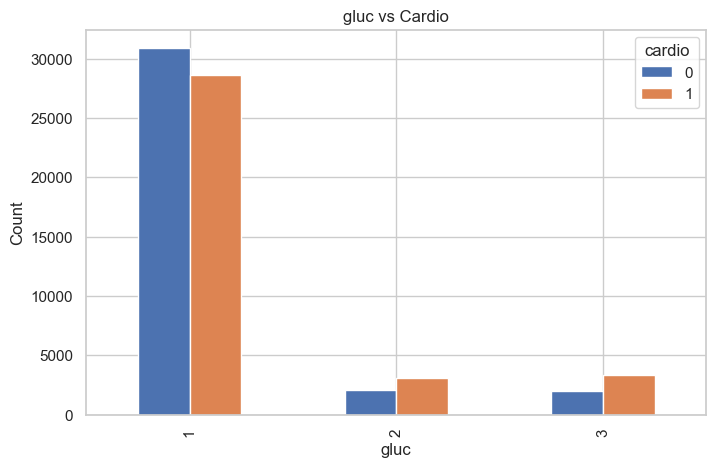

In [30]:
# these are important medical indicators

for col in ["cholesterol", "gluc"]:
    
    grouped = df.groupby([col, "cardio"]).size().unstack()
    
    grouped.plot(kind="bar")
    
    plt.title(f"{col} vs Cardio")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.show()

In [31]:
# using mean instead of count 

for col in ["cholesterol", "gluc", "smoke", "alco", "active"]:
    
    rate = df.groupby(col)["cardio"].mean()
    
    print(f"\nCardio rate by {col}:")
    print(rate.round(3))


Cardio rate by cholesterol:
cholesterol
1    0.440
2    0.602
3    0.765
Name: cardio, dtype: float64

Cardio rate by gluc:
gluc
1    0.481
2    0.593
3    0.622
Name: cardio, dtype: float64

Cardio rate by smoke:
smoke
0    0.502
1    0.475
Name: cardio, dtype: float64

Cardio rate by alco:
alco
0    0.501
1    0.484
Name: cardio, dtype: float64

Cardio rate by active:
active
0    0.536
1    0.491
Name: cardio, dtype: float64


In [32]:
print("""
EDA Summary:

1. Cardiovascular disease increases with age.
2. Blood pressure (ap_hi, ap_lo) and weight show strong differences between cardio groups.
3. Correlation analysis shows that the most important features vary slightly across age groups.
4. Clinical features are generally stronger predictors than lifestyle features.
5. Lifestyle factors still show some relationship but are less consistent.

These findings will be used to support the machine learning model later.
""")


EDA Summary:

1. Cardiovascular disease increases with age.
2. Blood pressure (ap_hi, ap_lo) and weight show strong differences between cardio groups.
3. Correlation analysis shows that the most important features vary slightly across age groups.
4. Clinical features are generally stronger predictors than lifestyle features.
5. Lifestyle factors still show some relationship but are less consistent.

These findings will be used to support the machine learning model later.

